# prep.post-cooccurrence

In this notebook, we will create a table containing the number of cooccurrences detected at each library. Hopefully, this one will allow us to assess the association between hosts and habitats with the level of bacteria-virus coocurrences.

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import networkx as nx
from daforfer import DaforferDB
from yaml import load, Loader
from daforfer import DaforferDB
import seaborn as sns
conf = load(open("conf.yaml"), Loader)
db = DaforferDB(conf['database'])
db.toc()

┌─────────────────────────┬────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│          name           │                                                                                  description                                                                                   │
│         varchar         │                                                                                    varchar                                                                                     │
├─────────────────────────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ D_sites                 │ This table contains key information about each of the libraries, such as their site, habitat and host                                                   

## Reading data

In [2]:
bacteria_hits = db.conn.sql('SELECT * FROM D_PABHits').df()
virus_hits = db.conn.sql('SELECT * FROM D_virusHits').df()

In [3]:
coocurrence_results = pd.read_csv(
    "output/coocurrence.virusbact-bylibrary.csv", sep=',', index_col=0
)
bacteria_names = bacteria_hits['scientific_name'].to_list()
virus_names = virus_hits['scientific_name'].to_list()
name_kingdom_map = {}
for b in bacteria_names:
    name_kingdom_map[b] = 'Bacteria'
for v in virus_names:
    name_kingdom_map[v] = 'Virus'
coocurrence_results['sp1_kingdom'] = coocurrence_results['sp1_name'].map(name_kingdom_map)
coocurrence_results['sp2_kingdom'] = coocurrence_results['sp2_name'].map(name_kingdom_map)
coocurrence_results = coocurrence_results.dropna(subset=['sp1_name', 'sp2_name'])
coocurrence_results = coocurrence_results.query('p_gt < 0.05 or p_lt < 0.05')
coocurrence_results

,sp1,sp2,sp1_inc,sp2_inc,obs_cooccur,prob_cooccur,exp_cooccur,p_lt,p_gt,sp1_name,sp2_name,sp1_kingdom,sp2_kingdom
72,7,139,13,27,4,0.004,1.2,0.99678,0.02154,Arabidopsis latent virus-1 RNA1,Turnip crinkle virus,Virus,Virus
75,7,155,13,27,4,0.004,1.2,0.99678,0.02154,Arabidopsis latent virus-1 RNA1,Youcai mosaic virus,Virus,Virus
101,15,47,10,188,3,0.021,6.3,0.03387,0.99352,Barley yellow dwarf virus - MAV,Cucumber mosaic virus RNA 3,Virus,Virus
134,17,47,19,188,8,0.040,11.9,0.04743,0.98406,Barley yellow dwarf virus - PAV,Cucumber mosaic virus RNA 3,Virus,Virus
165,22,26,27,27,20,0.008,2.4,1.00000,0.00000,Beet chlorosis virus,Beet mild yellowing virus,Virus,Virus
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1105,194,264,15,21,6,0.004,1.1,0.99999,0.00019,Duffyella gerundensis,Rhodococcoides fascians,Bacteria,Bacteria
1106,202,218,26,16,4,0.005,1.4,0.99243,0.03986,Frigoribacterium sp. Leaf164,Methylobacterium sp. Leaf125,Bacteria,Bacteria
1108,202,244,26,12,5,0.003,1.0,0.99984,0.00176,Frigoribacterium sp. Leaf164,Pseudomonas oryzihabitans,Bacteria,Bacteria
1109,202,264,26,21,5,0.006,1.8,0.99470,0.02586,Frigoribacterium sp. Leaf164,Rhodococcoides fascians,Bacteria,Bacteria


## Reading library data

In [4]:
library_data = db.conn.query('SELECT * FROM D_sites').df()
library_data

,site,library,habitat,n_extracts,host_taxon
0,C1,PV534,Crop,3,Diplotaxis erucoides
1,C1,PV535,Crop,17,Brassica oleracea
2,C1,PV538,Crop,8,Brassica oleracea
3,C1,PV540,Crop,1,Picris echioides
4,C1,PV544,Crop,4,Sisymbrium runcinatum
...,...,...,...,...,...
330,Z1,PV590,Crop,11,Zea mays
331,Z2,PV047,Crop,13,Zea mays
332,Z2,PV048,Crop,9,Desconocida 4
333,Z2,PV527,Crop,4,Convolvulus arvensis


## Assigning each library a number of coocurrences

There might be very sophisticated ways to do it using a couple elegant pandas expressions, but I m going to use the method that I employed ealier: converting the hits to networks, obtain the subgraph, and simply count the number of edges. 

### Creating the network

In [5]:
M = nx.MultiGraph()
for _, item in coocurrence_results.query('p_gt < 0.05').iterrows():
    if item.sp1_kingdom != item.sp2_kingdom:
        M.add_edge(item.sp1_name, item.sp2_name, sign="positive")
for _, item in coocurrence_results.query('p_lt < 0.05').iterrows():
    if item.sp1_kingdom != item.sp2_kingdom:
        M.add_edge(item.sp1_name, item.sp2_name, sign="negative")


### Creating a by library index of bacteria virus

This one states how many cooccurrences were detected in each library. 

In [6]:
all_hits = pd.concat([bacteria_hits, virus_hits])

library_cooccurrences = all_hits.groupby('library').apply(
    lambda x: M.subgraph(x.scientific_name).number_of_edges()
).reset_index()
library_cooccurrences = library_cooccurrences.rename(columns={0: 'number_cooccurrences_per_library'})
library_cooccurrences

/var/folders/xl/z7y434d524s8xpvqnb0gst580000gn/T/ipykernel_41944/1121366971.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  library_cooccurrences = all_hits.groupby('library').apply(


,library,number_cooccurrences_per_library
0,PV001,0
1,PV002,0
2,PV003,0
3,PV003bgi,1
4,PV004bgi,1
...,...,...
294,PV586,0
295,PV587,0
296,PV588,0
297,PV589,0


Now, we will sort of manually verify that this is right. `PV004bgi`is associated to two cooccurrences. 

In [7]:
all_hits.query('library == "PV004bgi"')

,library,taxid,scientific_name,is_pab,pab_type,acronym
2,PV004bgi,29448,Bradyrhizobium elkanii,True,pab_symbiont,NaN
29,PV004bgi,12199,Cowpea aphid-borne mosaic virus,NaN,NaN,CABMV
30,PV004bgi,12305,Cucumber mosaic virus RNA 3,NaN,NaN,CMV3
31,PV004bgi,146500,Watermelon mosaic virus,NaN,NaN,WMV


In [8]:
coocurrence_results.query('sp1_name == "Bradyrhizobium elkanii" or sp2_name == "Bradyrhizobium elkanii"')# query('sp1_name == "Cucumber mosaic virus RNA 3" or sp2_name == "Cucumber mosaic virus RNA 3"')

,sp1,sp2,sp1_inc,sp2_inc,obs_cooccur,prob_cooccur,exp_cooccur,p_lt,p_gt,sp1_name,sp2_name,sp1_kingdom,sp2_kingdom
671,87,174,134,9,0,0.013,4.0,0.00429,1.00000,Pelargonium zonate spot virus RNA 3,Bradyrhizobium elkanii,Virus,Bacteria
816,109,174,111,9,0,0.011,3.3,0.01428,1.00000,Rubus chlorotic mottle virus,Bradyrhizobium elkanii,Virus,Bacteria
905,124,174,106,9,0,0.011,3.2,0.01818,1.00000,Tobacco mild green mosaic virus,Bradyrhizobium elkanii,Virus,Bacteria
1074,147,174,59,9,8,0.006,1.8,1.00000,0.00001,Watermelon mosaic virus,Bradyrhizobium elkanii,Virus,Bacteria


In [9]:
library_cooccurrences

,library,number_cooccurrences_per_library
0,PV001,0
1,PV002,0
2,PV003,0
3,PV003bgi,1
4,PV004bgi,1
...,...,...
294,PV586,0
295,PV587,0
296,PV588,0
297,PV589,0


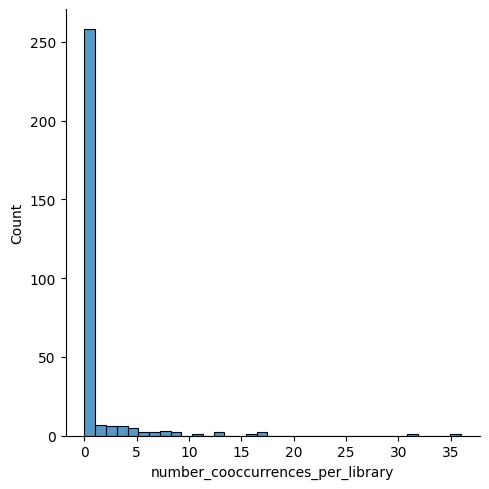

In [10]:
sns.displot(library_cooccurrences, x='number_cooccurrences_per_library')

### Merge with library data to add the missing libraries

Some libraries (~25 of them) do not appear in this analysis. We will fill their place with zeros to make the analysis consistent. 

In [11]:
libraries = db.conn.sql("SELECT * FROM D_sites").df()
libraries = libraries.drop_duplicates('library')['library'].reset_index()
libraries

,index,library
0,0,PV534
1,1,PV535
2,2,PV538
3,3,PV540
4,4,PV544
...,...,...
318,330,PV590
319,331,PV047
320,332,PV048
321,333,PV527


In [12]:
total_cooccurrences_premerge = library_cooccurrences.number_cooccurrences_per_library.sum()

In [13]:
library_cooccurrences = pd.merge(libraries[['library']], library_cooccurrences, on='library', how='left')
library_cooccurrences

,library,number_cooccurrences_per_library
0,PV534,0.0
1,PV535,0.0
2,PV538,0.0
3,PV540,0.0
4,PV544,5.0
...,...,...
318,PV590,0.0
319,PV047,0.0
320,PV048,0.0
321,PV527,5.0


In [14]:
total_cooccurrences_postmerge = library_cooccurrences.number_cooccurrences_per_library.sum()
assert(total_cooccurrences_premerge == total_cooccurrences_postmerge)
assert(len(library_cooccurrences) == 323)

### Save

In [15]:
db.toc().df()

,name,description
0,D_sites,This table contains key information about each...
1,D_bacteriaHits,This table contains all the MOTUS hits obtaine...
2,D_PABHits,This table contains all the PAB MOTUS hits. It...
3,d_TableS1,Table S1: Library sites and context
4,D_PABOTUs,This table summarizes most of the information ...
5,D_virusHits,This table contains all the virus hits. It con...
6,D_coocDetections,Library code and number of cooccurring pairs d...
7,D_coocPairDetections,Number of cooccurring pairs per library. Dedup...
8,D_Site_level_div,Site-level diversity and number of cooccurring...
9,D_Habitat_level_div,Habitat-level diversity and number of cooccurr...


In [16]:
db.save_dataframe(
    library_cooccurrences, 
    table_name='D_coocDetections', description='Library code and number of cooccurring pairs detected')

Saved D_coocDetections to db.2025-11-17


## Assigning each library all the detections

This will allow later-deduplication. We will consider all pairs of organisms involved in each library, using a single index that identifies the pair of cooccurring organisms.

In [17]:
all_hits = pd.concat([bacteria_hits, virus_hits])
library_cooccurrent_pair_detections = []
for lib in all_hits['library'].unique():

    library_hits = all_hits.query('library == "{:0}"'.format(lib))

    u = list(M.subgraph(library_hits.scientific_name).edges())
    cooccurrences = ['-'.join(sorted([item[0], item[1]])) for item in u]

    for item in cooccurrences:
        library_cooccurrent_pair_detections.append({
            'library': lib, 'pair': item
        })
library_cooccurrent_pair_detections_df = pd.DataFrame.from_records(library_cooccurrent_pair_detections)
library_cooccurrent_pair_detections_df

,library,pair
0,PV003bgi,Bradyrhizobium elkanii-Watermelon mosaic virus
1,PV004bgi,Bradyrhizobium elkanii-Watermelon mosaic virus
2,PV005bgi,Bradyrhizobium elkanii-Watermelon mosaic virus
3,PV007bgi,Bradyrhizobium elkanii-Watermelon mosaic virus
4,PV012bgi,Bradyrhizobium elkanii-Watermelon mosaic virus
...,...,...
332,PV544,Beet western yellows virus-Rhodococcoides fasc...
333,PV544,Rhodococcoides fascians-Rubus chlorotic mottle...
334,PV544,Agrobacterium tumefaciens-Beet western yellows...
335,PV544,Beet western yellows virus-Sphingomonas sp. Le...


In [18]:
library_cooccurrent_pair_detections_df.drop_duplicates('pair', keep='first')

,library,pair
0,PV003bgi,Bradyrhizobium elkanii-Watermelon mosaic virus
8,PV022,Curtobacterium flaccumfaciens-Tobacco mosaic v...
9,PV022,Rhizobium sp. NFR03-Tobacco mosaic virus
10,PV022,Curtobacterium flaccumfaciens-Tomato mosaic virus
13,PV024,Agrobacterium tumefaciens-Pepper mild mottle v...
15,PV032,Frigoribacterium sp. Leaf164-Pepper mild mottl...
16,PV034,Methylobacterium sp. Leaf125-Tobacco mild gree...
18,PV046,Duffyella gerundensis-Tobacco mild green mosai...
19,PV049,Pantoea ananatis-Pepper mild mottle virus
21,PV059,Beet chlorosis virus-Duffyella gerundensis


We obtain 51 interactions at most, because 7 of the 57 cooccurrences were positive. The difference (1) might be attributed to a negative cooccurrent pair that was detected somewhere.

In [19]:
M_edges = pd.DataFrame.from_records(list(M.edges(data=True))).rename(
    columns={0: 'org1', 1: 'org2'}
)
M_edges['pair'] = M_edges.apply(lambda x: "-".join(sorted([x.org1, x.org2])), axis=1)
M_edges = M_edges.drop_duplicates('pair')
M_edges[M_edges.pair.isin(library_cooccurrent_pair_detections_df.pair)]

,org1,org2,2,pair
0,Beet chlorosis virus,Duffyella gerundensis,{'sign': 'positive'},Beet chlorosis virus-Duffyella gerundensis
1,Beet chlorosis virus,Frigoribacterium sp. Leaf164,{'sign': 'positive'},Beet chlorosis virus-Frigoribacterium sp. Leaf164
2,Beet chlorosis virus,Pseudomonas oryzihabitans,{'sign': 'positive'},Beet chlorosis virus-Pseudomonas oryzihabitans
3,Beet chlorosis virus,Rhodococcoides fascians,{'sign': 'positive'},Beet chlorosis virus-Rhodococcoides fascians
4,Duffyella gerundensis,Pepper mild mottle virus,{'sign': 'positive'},Duffyella gerundensis-Pepper mild mottle virus
5,Duffyella gerundensis,Tobacco mild green mosaic virus,{'sign': 'positive'},Duffyella gerundensis-Tobacco mild green mosai...
6,Duffyella gerundensis,Youcai mosaic virus,{'sign': 'positive'},Duffyella gerundensis-Youcai mosaic virus
7,Frigoribacterium sp. Leaf164,Beet mild yellowing virus,{'sign': 'positive'},Beet mild yellowing virus-Frigoribacterium sp....
8,Frigoribacterium sp. Leaf164,Pepper mild mottle virus,{'sign': 'positive'},Frigoribacterium sp. Leaf164-Pepper mild mottl...
9,Frigoribacterium sp. Leaf164,Turnip yellows virus,{'sign': 'positive'},Frigoribacterium sp. Leaf164-Turnip yellows virus


In this case, it won't be a good idea to merge with libraries, because we will compute the values from deduplicated dataframes.

In [20]:
db.save_dataframe(
    library_cooccurrent_pair_detections_df,
    table_name='D_coocPairDetections',
    description='Number of cooccurring pairs per library. Deduplication can help assessing how many detections took place at library level'
)

Saved D_coocPairDetections to db.2025-11-17


In [21]:
db.close()